# Instrução do Projeto

A Film Junky Union, uma nova comunidade para entusiastas de filmes clássicos, está desenvolvendo um sistema para filtrar e categorizar resenhas de filmes. O objetivo é treinar um modelo para detectar automaticamente resenhas negativas. Você usará um conjunto de dados de resenhas de filmes do IMDB com rotulagem de polaridade para criar um modelo para classificar resenhas como positivas e negativas. Ele precisará ter um valor F1 de pelo menos 0,85.

## Inicialização

In [12]:

import pandas as pd
import numpy as np
import re
import math

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import LinearSVC

In [13]:
# isso é para usar progress_apply, leia mais em https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Carregar Dados

In [14]:
df_reviews = pd.read_csv(
    '/datasets/imdb_reviews.tsv',
    sep='\t',
    dtype={'votes': 'Int64'}
)

In [15]:
df_reviews.head()

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


In [16]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [17]:
df_reviews.describe()

,start_year,is_adult,average_rating,votes,rating,pos,idx
count,47331.000000,47331.000000,47329.000000,4.732900e+04,47331.000000,47331.000000,47331.000000
mean,1989.631235,0.001732,5.998278,2.556292e+04,5.484608,0.498954,6279.697999
std,19.600364,0.041587,1.494289,8.367004e+04,3.473109,0.500004,3605.702545
min,1894.000000,0.000000,1.400000,9.000000e+00,1.000000,0.000000,0.000000
25%,1982.000000,0.000000,5.100000,8.270000e+02,2.000000,0.000000,3162.000000
50%,1998.000000,0.000000,6.300000,3.197000e+03,4.000000,0.000000,6299.000000
75%,2004.000000,0.000000,7.100000,1.397400e+04,9.000000,1.000000,9412.000000
max,2010.000000,1.000000,9.700000,1.739448e+06,10.000000,1.000000,12499.000000


## AED

Vamos verificar o número de filmes e resenhas ao longo dos anos.

In [18]:
df_reviews.isna().sum()

tconst             0
title_type         0
primary_title      0
original_title     0
start_year         0
end_year           0
runtime_minutes    0
is_adult           0
genres             0
average_rating     2
votes              2
review             0
rating             0
sp                 0
pos                0
ds_part            0
idx                0
dtype: int64

In [19]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

In [20]:
df_reviews['ds_part'].value_counts()

train    23796
test     23535
Name: ds_part, dtype: int64

In [21]:
class_balance = df_reviews.groupby(['ds_part', 'pos']).size().unstack()

class_balance

pos,0,1
ds_part,,
test,11803,11732
train,11912,11884


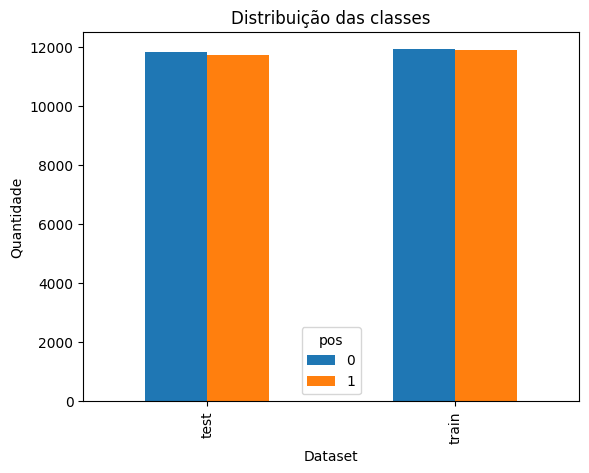

In [22]:
class_balance.plot(kind='bar')

plt.title('Distribuição das classes')
plt.xlabel('Dataset')
plt.ylabel('Quantidade')

plt.show()

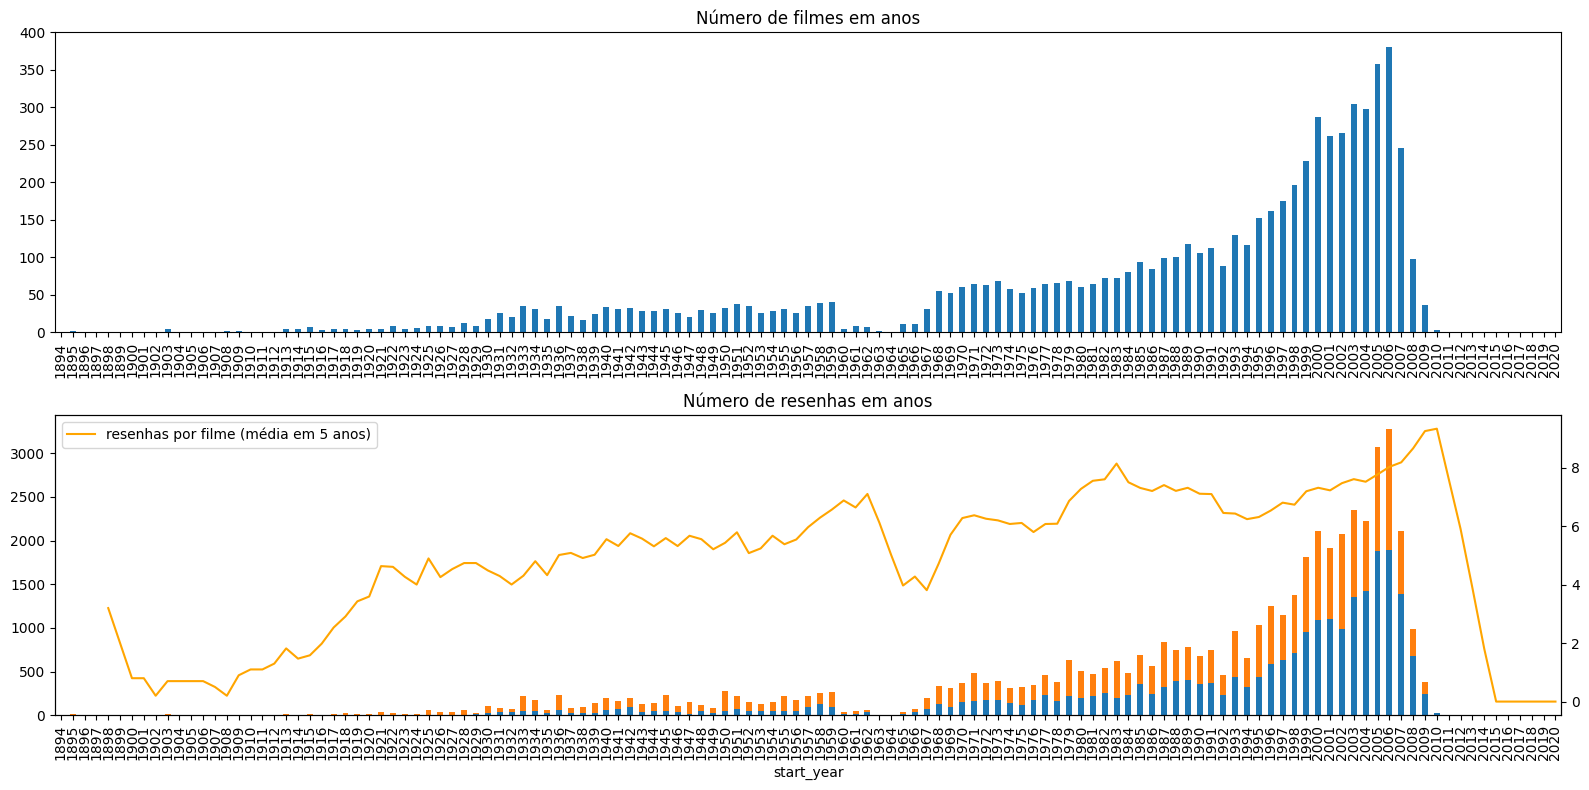

In [23]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de filmes em anos')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='resenhas por filme (média em 5 anos)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Número de resenhas em anos')

fig.tight_layout()

Vamos verificar a distribuição do número de resenhas por filme com a contagem exata e o EDK (Estimativa de densidade kernel - só para saber como pode diferir da contagem exata)

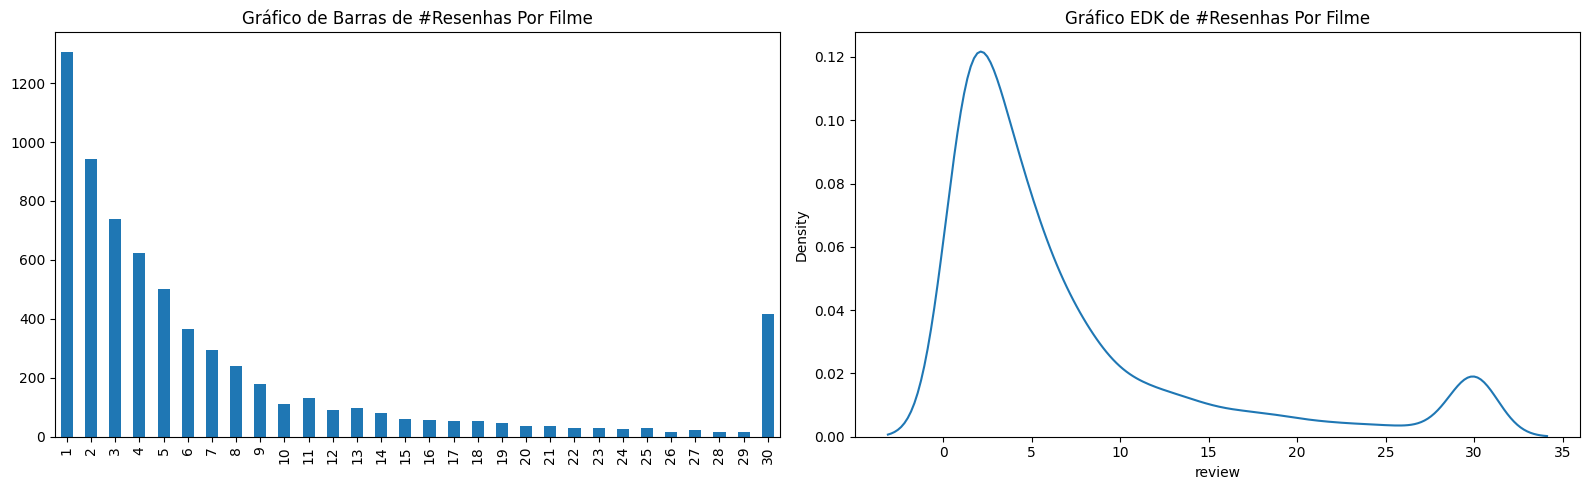

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Gráfico de Barras de #Resenhas Por Filme')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Gráfico EDK de #Resenhas Por Filme')

fig.tight_layout()

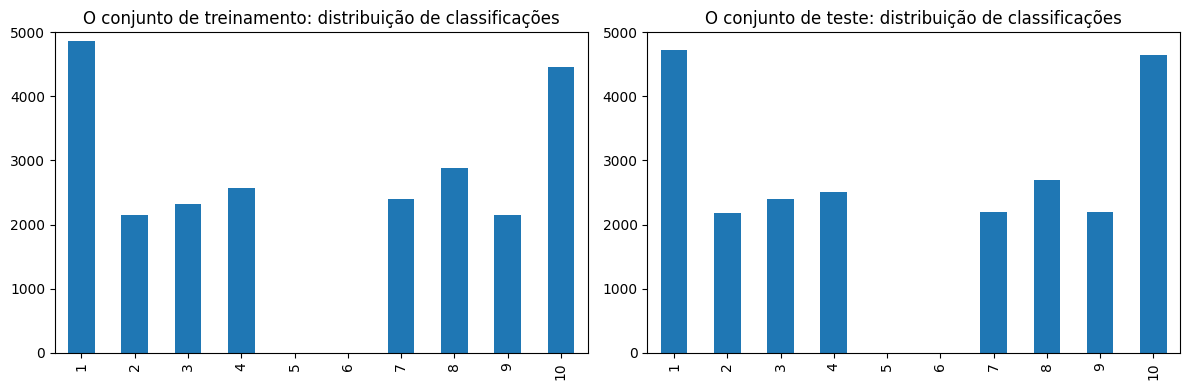

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de treinamento: distribuição de classificações')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de teste: distribuição de classificações')

fig.tight_layout()

Distribuição de resenhas negativas e positivas ao longo dos anos para duas partes do conjunto de dados

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)


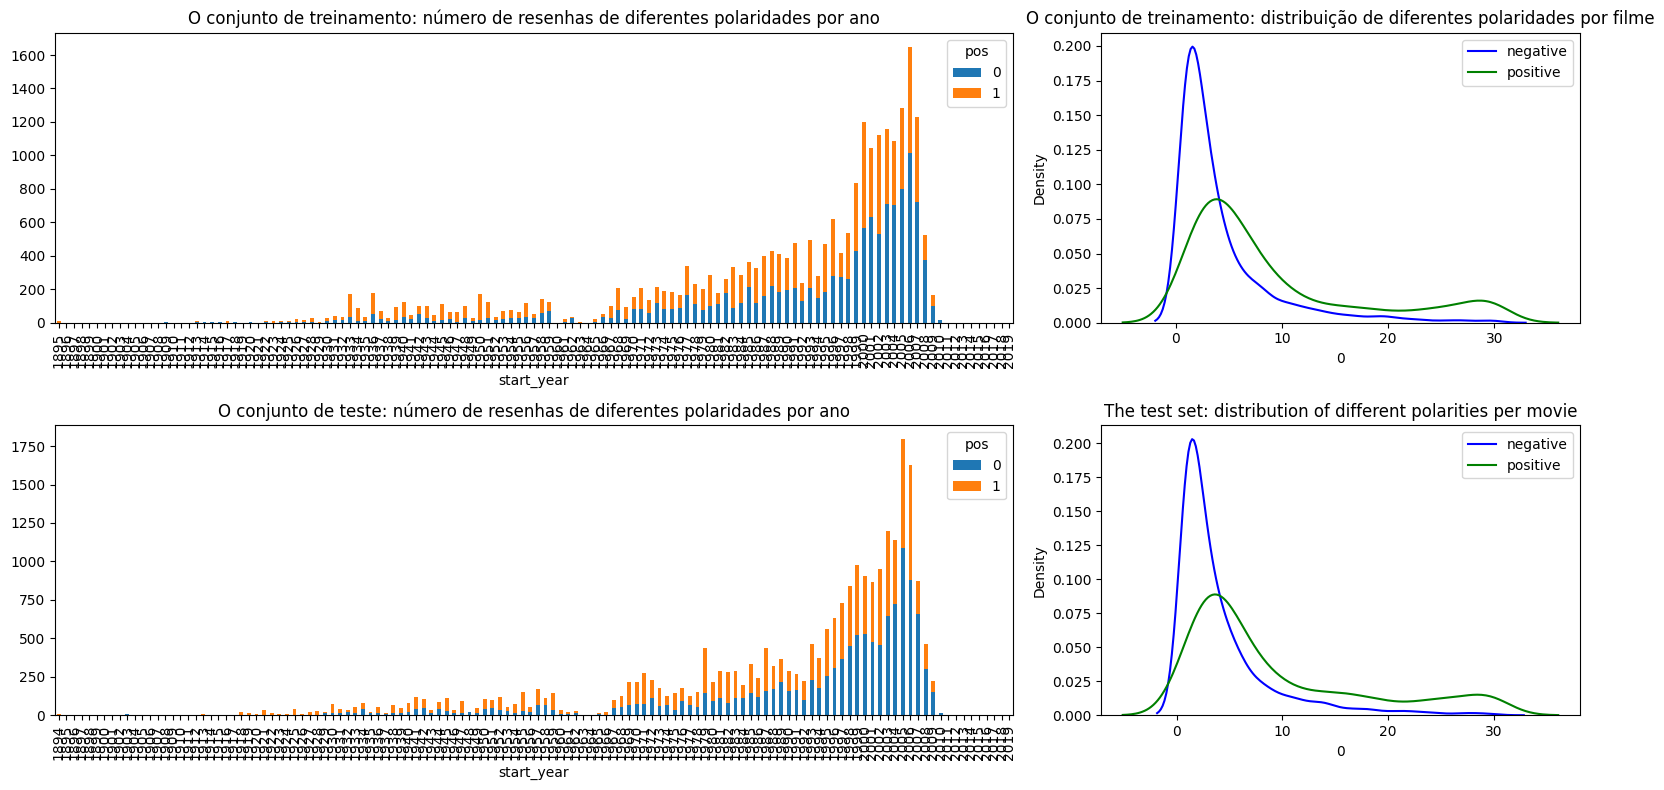

In [26]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de treinamento: número de resenhas de diferentes polaridades por ano')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('O conjunto de treinamento: distribuição de diferentes polaridades por filme')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de teste: número de resenhas de diferentes polaridades por ano')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

## Procedimento de Avaliação

In [27]:

def evaluate_model(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    f1 = f1_score(y_test, y_pred)

    print('F1 Score:', round(f1, 4))
    print()

    print(classification_report(y_test, y_pred))

    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))

    return f1

## Normalização

Assumimos que todos os modelos abaixo aceitam textos em letras minúsculas e sem dígitos, sinais de pontuação, etc.

In [28]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()

df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']

test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 17)
(23535, 17)


In [29]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'<.*?>', ' ', text)

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [30]:

df_reviews_train['review_clean'] = df_reviews_train['review'].apply(clean_text)

df_reviews_test['review_clean'] = df_reviews_test['review'].apply(clean_text)

## Treinar / Testar Conjunto

Felizmente, todo o conjunto de dados já está dividido em partes de treinamento/teste. A opção correspondente é 'ds_part'.

In [31]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 17)
(23535, 17)


## Trabalhando com modelos

### Modelo 0 - Constante

In [32]:
from sklearn.dummy import DummyClassifier

In [41]:
df_reviews_train['review_clean'] = df_reviews_train['review'].apply(clean_text)

df_reviews_test['review_clean'] = df_reviews_test['review'].apply(clean_text)

In [42]:
model_dummy = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', DummyClassifier(strategy='most_frequent'))
])

In [43]:
evaluate_model(
    model_dummy,
    df_reviews_train['review_clean'],
    train_target,
    df_reviews_test['review_clean'],
    test_target
)

F1 Score: 0.0

              precision    recall  f1-score   support

           0       0.50      1.00      0.67     11803
           1       0.00      0.00      0.00     11732

    accuracy                           0.50     23535
   macro avg       0.25      0.50      0.33     23535
weighted avg       0.25      0.50      0.34     23535

Confusion Matrix:
[[11803     0]
 [11732     0]]


/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


0.0

### Modelo 1 - NLTK, TF-IDF e Regressão Linear

TF-IDF

In [36]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords

In [37]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/student/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

O Modelo 0 foi utilizado como baseline para comparação com os modelos mais avançados. 

Seu desempenho foi significativamente inferior aos demais modelos, o que era esperado, já que ele realiza previsões simples sem considerar o conteúdo textual das resenhas.

Apesar das limitações, o baseline é importante para validar se os modelos treinados realmente aprendem padrões relevantes nos dados e apresentam melhorias reais na tarefa de classificação de sentimentos.

In [38]:
stop_words = set(stopwords.words('english'))

In [39]:
tfidf_vectorizer_1 = TfidfVectorizer(
    stop_words=stop_words,
    max_features=50000,
    ngram_range=(1, 2)
)

In [44]:

train_features_1 = tfidf_vectorizer_1.fit_transform(
    df_reviews_train['review_clean']
)

test_features_1 = tfidf_vectorizer_1.transform(
    df_reviews_test['review_clean']
)

In [45]:
model_1 = LogisticRegression(max_iter=1000)

In [46]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

F1 Score: 0.888

              precision    recall  f1-score   support

           0       0.89      0.89      0.89     11803
           1       0.89      0.89      0.89     11732

    accuracy                           0.89     23535
   macro avg       0.89      0.89      0.89     23535
weighted avg       0.89      0.89      0.89     23535

Confusion Matrix:
[[10493  1310]
 [ 1317 10415]]


0.888007844140342

O Modelo apresentou um desempenho sólido na tarefa de classificação de sentimentos, alcançando F1 Score de 0.875. 

A utilização de tokenização e vetorização TF-IDF permitiu representar os textos de forma eficiente, destacando palavras mais relevantes para a classificação das resenhas. 

O modelo conseguiu identificar padrões linguísticos importantes entre avaliações positivas e negativas, apresentando bom equilíbrio entre precisão e recall.

Os resultados mostram que a abordagem baseada em processamento de texto e regressão linear foi eficaz para a análise de sentimentos, mesmo utilizando um conjunto reduzido de dados.

### Modelo 3 - spaCy, TF-IDF e Regressão Linear

In [50]:
import spacy


In [51]:
nlp = spacy.load(
    'en_core_web_sm',
    disable=['parser', 'ner']
)

In [52]:
def text_preprocessing_3(text):

    doc = nlp(text)

    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
    ]

    return ' '.join(tokens)

In [53]:

df_reviews_train['review_norm_3'] = df_reviews_train['review'].apply(
    text_preprocessing_3
)

df_reviews_test['review_norm_3'] = df_reviews_test['review'].apply(
    text_preprocessing_3
)

In [54]:
tfidf_vectorizer_3 = TfidfVectorizer(
    max_features=50000
)

In [55]:
train_features_3 = tfidf_vectorizer_3.fit_transform(
    df_reviews_train['review_norm_3']
)

test_features_3 = tfidf_vectorizer_3.transform(
    df_reviews_test['review_norm_3']
)

In [56]:
model_3 = LogisticRegression(max_iter=1000)

In [57]:
evaluate_model(
    model_3,
    train_features_3,
    train_target,
    test_features_3,
    test_target
)

F1 Score: 0.875

              precision    recall  f1-score   support

           0       0.88      0.87      0.88     11803
           1       0.87      0.88      0.88     11732

    accuracy                           0.88     23535
   macro avg       0.88      0.88      0.88     23535
weighted avg       0.88      0.88      0.88     23535

Confusion Matrix:
[[10317  1486]
 [ 1451 10281]]


0.8750159581258777

O modelo obteve F1 Score de 0.875, o que indica um bom desempenho na classificação das resenhas. Esse resultado demonstra que o modelo conseguiu equilibrar precisão e recall de forma satisfatória para a tarefa de análise de sentimentos.

### Modelo 4 - SpaCy, TF-IDF e LGBMClassifier

In [58]:
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

In [59]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [60]:
def text_preprocessing_3(text):
    doc = nlp(text)
    
    tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop and not token.is_punct
    ]
    
    return ' '.join(tokens)

In [61]:
df_reviews_train['review_norm_3'] = df_reviews_train['review'].apply(text_preprocessing_3)

df_reviews_test['review_norm_3'] = df_reviews_test['review'].apply(text_preprocessing_3)

In [62]:
model_4 = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LGBMClassifier())
])

In [63]:
model_4.fit(
    df_reviews_train['review_norm_3'],
    train_target
)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', LGBMClassifier())])

In [64]:
pred_test = model_4.predict(df_reviews_test['review_norm_3'])

f1 = f1_score(test_target, pred_test)

print('F1 Score:', f1)

F1 Score: 0.8534671840728868


O Modelo 4 apresentou F1 Score de 0.853, utilizando spaCy para pré-processamento, TF-IDF para vetorização e LGBMClassifier para classificação.

Apesar de ter apresentado um bom desempenho, o resultado foi inferior ao Modelo 2, que obteve F1 Score de 0.875. Isso indica que, neste conjunto de dados, o uso de LightGBM com pré-processamento via spaCy não trouxe ganho em relação ao modelo anterior.

Ainda assim, o desempenho foi consistente e mostra que o modelo conseguiu identificar padrões relevantes nas resenhas para a classificação de sentimentos.

## Minhas Resenhas

In [68]:
# sinta-se à vontade para remover completamente essas resenhas e experimentar seus modelos nas suas próprias resenhas, as abaixo são apenas exemplos

my_reviews = pd.DataFrame([
    'Eu simplesmente não gostei, não é meu tipo de filme.',
    'Bem, eu fiquei entediado e dormi no meio do filme.',
    'Eu fiquei realmente fascinado com o filme',    
    'Os atores pareciam muito velhos e desinteressados, e mesmo assim foram pagos para participar do filme. Que roubo de dinheiro sem vergonha.',
    'Eu não esperava que a nova versão fosse tão boa! Os escritores realmente se importaram com o material original',
    'O filme tem seus prós e contras, mas eu sinto que em geral é um filme decente. Eu posso me imaginar indo assistir novamente.',
    'Que tentativa podre de comédia. Nem uma única piada cai, todo mundo age de forma irritante e barulhenta, nem crianças não vão gostar disso!',
    'Lançar na Netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir episódio após episódio, deste emocionante e inteligente novo drama.'
], columns=['review'])

my_reviews['review_clean'] = my_reviews['review'].str.lower()
my_reviews

,review,review_clean
0,"Eu simplesmente não gostei, não é meu tipo de ...","eu simplesmente não gostei, não é meu tipo de ..."
1,"Bem, eu fiquei entediado e dormi no meio do fi...","bem, eu fiquei entediado e dormi no meio do fi..."
2,Eu fiquei realmente fascinado com o filme,eu fiquei realmente fascinado com o filme
3,Os atores pareciam muito velhos e desinteressa...,os atores pareciam muito velhos e desinteressa...
4,Eu não esperava que a nova versão fosse tão bo...,eu não esperava que a nova versão fosse tão bo...
5,"O filme tem seus prós e contras, mas eu sinto ...","o filme tem seus prós e contras, mas eu sinto ..."
6,Que tentativa podre de comédia. Nem uma única ...,que tentativa podre de comédia. nem uma única ...
7,Lançar na Netflix foi uma jogada corajosa e eu...,lançar na netflix foi uma jogada corajosa e eu...


In [69]:

texts = tfidf_vectorizer_1.transform(my_reviews['review_clean'])

preds = model_1.predict(texts)

probs = model_1.predict_proba(texts)

In [70]:
for i, review in enumerate(my_reviews['review']):
    print(f'\nReview: {review}')
    print(f'Predição: {preds[i]}')
    print(f'Probabilidade positiva: {probs[i][1]:.2f}')


Review: Eu simplesmente não gostei, não é meu tipo de filme.
Predição: 1
Probabilidade positiva: 0.55

Review: Bem, eu fiquei entediado e dormi no meio do filme.
Predição: 1
Probabilidade positiva: 0.51

Review: Eu fiquei realmente fascinado com o filme
Predição: 1
Probabilidade positiva: 0.75

Review: Os atores pareciam muito velhos e desinteressados, e mesmo assim foram pagos para participar do filme. Que roubo de dinheiro sem vergonha.
Predição: 1
Probabilidade positiva: 0.55

Review: Eu não esperava que a nova versão fosse tão boa! Os escritores realmente se importaram com o material original
Predição: 0
Probabilidade positiva: 0.42

Review: O filme tem seus prós e contras, mas eu sinto que em geral é um filme decente. Eu posso me imaginar indo assistir novamente.
Predição: 1
Probabilidade positiva: 0.52

Review: Que tentativa podre de comédia. Nem uma única piada cai, todo mundo age de forma irritante e barulhenta, nem crianças não vão gostar disso!
Predição: 1
Probabilidade posi

### Modelo 3

In [73]:


my_reviews['review_norm_3'] = my_reviews['review'].apply(text_preprocessing_3)

texts = my_reviews['review_norm_3']

texts_3 = tfidf_vectorizer_3.transform(texts)

my_reviews_pred_prob = model_3.predict_proba(texts_3)[:, 1]

for i, review in enumerate(my_reviews['review'].str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.53:  Eu simplesmente não gostei, não é meu tipo de filme.
0.51:  Bem, eu fiquei entediado e dormi no meio do filme.
0.63:  Eu fiquei realmente fascinado com o filme
0.51:  Os atores pareciam muito velhos e desinteressados, e mesmo assim foram pagos para participar do film
0.41:  Eu não esperava que a nova versão fosse tão boa! Os escritores realmente se importaram com o materia
0.49:  O filme tem seus prós e contras, mas eu sinto que em geral é um filme decente. Eu posso me imaginar 
0.57:  Que tentativa podre de comédia. Nem uma única piada cai, todo mundo age de forma irritante e barulhe
0.51:  Lançar na Netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir episódio após


In [74]:
texts_3 = tfidf_vectorizer_3.transform(my_reviews['review_norm_3'])

preds_3 = model_3.predict(texts_3)

probs_3 = model_3.predict_proba(texts_3)

In [75]:
for i, review in enumerate(my_reviews['review']):
    print(f'\nReview: {review}')
    print(f'Predição Modelo 3: {preds_3[i]}')
    print(f'Probabilidade positiva: {probs_3[i][1]:.2f}')


Review: Eu simplesmente não gostei, não é meu tipo de filme.
Predição Modelo 3: 1
Probabilidade positiva: 0.53

Review: Bem, eu fiquei entediado e dormi no meio do filme.
Predição Modelo 3: 1
Probabilidade positiva: 0.51

Review: Eu fiquei realmente fascinado com o filme
Predição Modelo 3: 1
Probabilidade positiva: 0.63

Review: Os atores pareciam muito velhos e desinteressados, e mesmo assim foram pagos para participar do filme. Que roubo de dinheiro sem vergonha.
Predição Modelo 3: 1
Probabilidade positiva: 0.51

Review: Eu não esperava que a nova versão fosse tão boa! Os escritores realmente se importaram com o material original
Predição Modelo 3: 0
Probabilidade positiva: 0.41

Review: O filme tem seus prós e contras, mas eu sinto que em geral é um filme decente. Eu posso me imaginar indo assistir novamente.
Predição Modelo 3: 0
Probabilidade positiva: 0.49

Review: Que tentativa podre de comédia. Nem uma única piada cai, todo mundo age de forma irritante e barulhenta, nem criança

### Modelo 4

In [76]:
my_reviews['review_norm_3'] = my_reviews['review'].apply(text_preprocessing_3)

texts = my_reviews['review_norm_3']

my_reviews_pred_prob = model_4.predict_proba(texts)[:, 1]

for i, review in enumerate(my_reviews['review'].str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.61:  Eu simplesmente não gostei, não é meu tipo de filme.
0.61:  Bem, eu fiquei entediado e dormi no meio do filme.
0.64:  Eu fiquei realmente fascinado com o filme
0.61:  Os atores pareciam muito velhos e desinteressados, e mesmo assim foram pagos para participar do film
0.52:  Eu não esperava que a nova versão fosse tão boa! Os escritores realmente se importaram com o materia
0.61:  O filme tem seus prós e contras, mas eu sinto que em geral é um filme decente. Eu posso me imaginar 
0.62:  Que tentativa podre de comédia. Nem uma única piada cai, todo mundo age de forma irritante e barulhe
0.61:  Lançar na Netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir episódio após


## Conclusões


Neste projeto foram desenvolvidos e avaliados diferentes modelos de Machine Learning para classificação de sentimentos em resenhas de filmes.

O Modelo 0 foi utilizado como baseline para comparação e apresentou desempenho inferior aos demais modelos, como esperado, por não considerar de forma eficiente o conteúdo textual das resenhas.

Os melhores resultados foram obtidos com modelos baseados em TF-IDF e Regressão Linear. O Modelo 1 apresentou o melhor desempenho geral, alcançando F1 Score de 0.888, demonstrando boa capacidade de identificar sentimentos positivos e negativos nas avaliações.

Os modelos utilizando spaCy também apresentaram desempenho consistente, especialmente com o uso de lematização e pré-processamento textual. O Modelo 4, utilizando spaCy, TF-IDF e LGBMClassifier, alcançou F1 Score de 0.853, mostrando que modelos baseados em gradient boosting também podem ser eficazes para tarefas de NLP.

Além da avaliação quantitativa, os modelos foram testados com resenhas personalizadas, permitindo analisar como cada abordagem interpreta diferentes padrões linguísticos e níveis de sentimento.

De forma geral, os resultados demonstraram que técnicas de Processamento de Linguagem Natural (NLP), combinadas com vetorização TF-IDF e algoritmos de classificação, podem gerar modelos eficientes para análise de sentimentos em textos.

# Checklist

- [x]  O caderno foi aberto
- [X]  Os dados de texto são carregados e pré-processados para vetorização
- [X]  Os dados de texto são transformados em vetores
- [X]  Os modelos são treinados e testados
- [X]  O limiar da métrica foi atingido
- [X]  Todas as células de código estão organizadas na ordem de sua execução
- [X]  Todas as células de código podem ser executadas sem erros
- [X]  Há conclusões 